In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("bearingdata.csv")
df

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1
...,...,...,...,...,...,...,...,...,...,...
2295,0.21425,-0.19839,0.010769,0.064100,0.064983,-0.212497,-0.119312,3.297037,6.034174,Normal_1
2296,0.21967,-0.20882,0.013136,0.068654,0.069883,-0.061308,-0.295122,3.143410,5.319958,Normal_1
2297,0.20799,-0.21613,0.012571,0.067128,0.068279,-0.154754,-0.071405,3.046161,5.431299,Normal_1
2298,0.21425,-0.22405,0.012608,0.066813,0.067977,-0.326966,0.023662,3.151821,5.391672,Normal_1


In [23]:
df['fault'].unique()

array(['Ball_007_1', 'Ball_014_1', 'Ball_021_1', 'IR_007_1', 'IR_014_1',
       'IR_021_1', 'OR_007_6_1', 'OR_014_6_1', 'OR_021_6_1', 'Normal_1'],
      dtype=object)

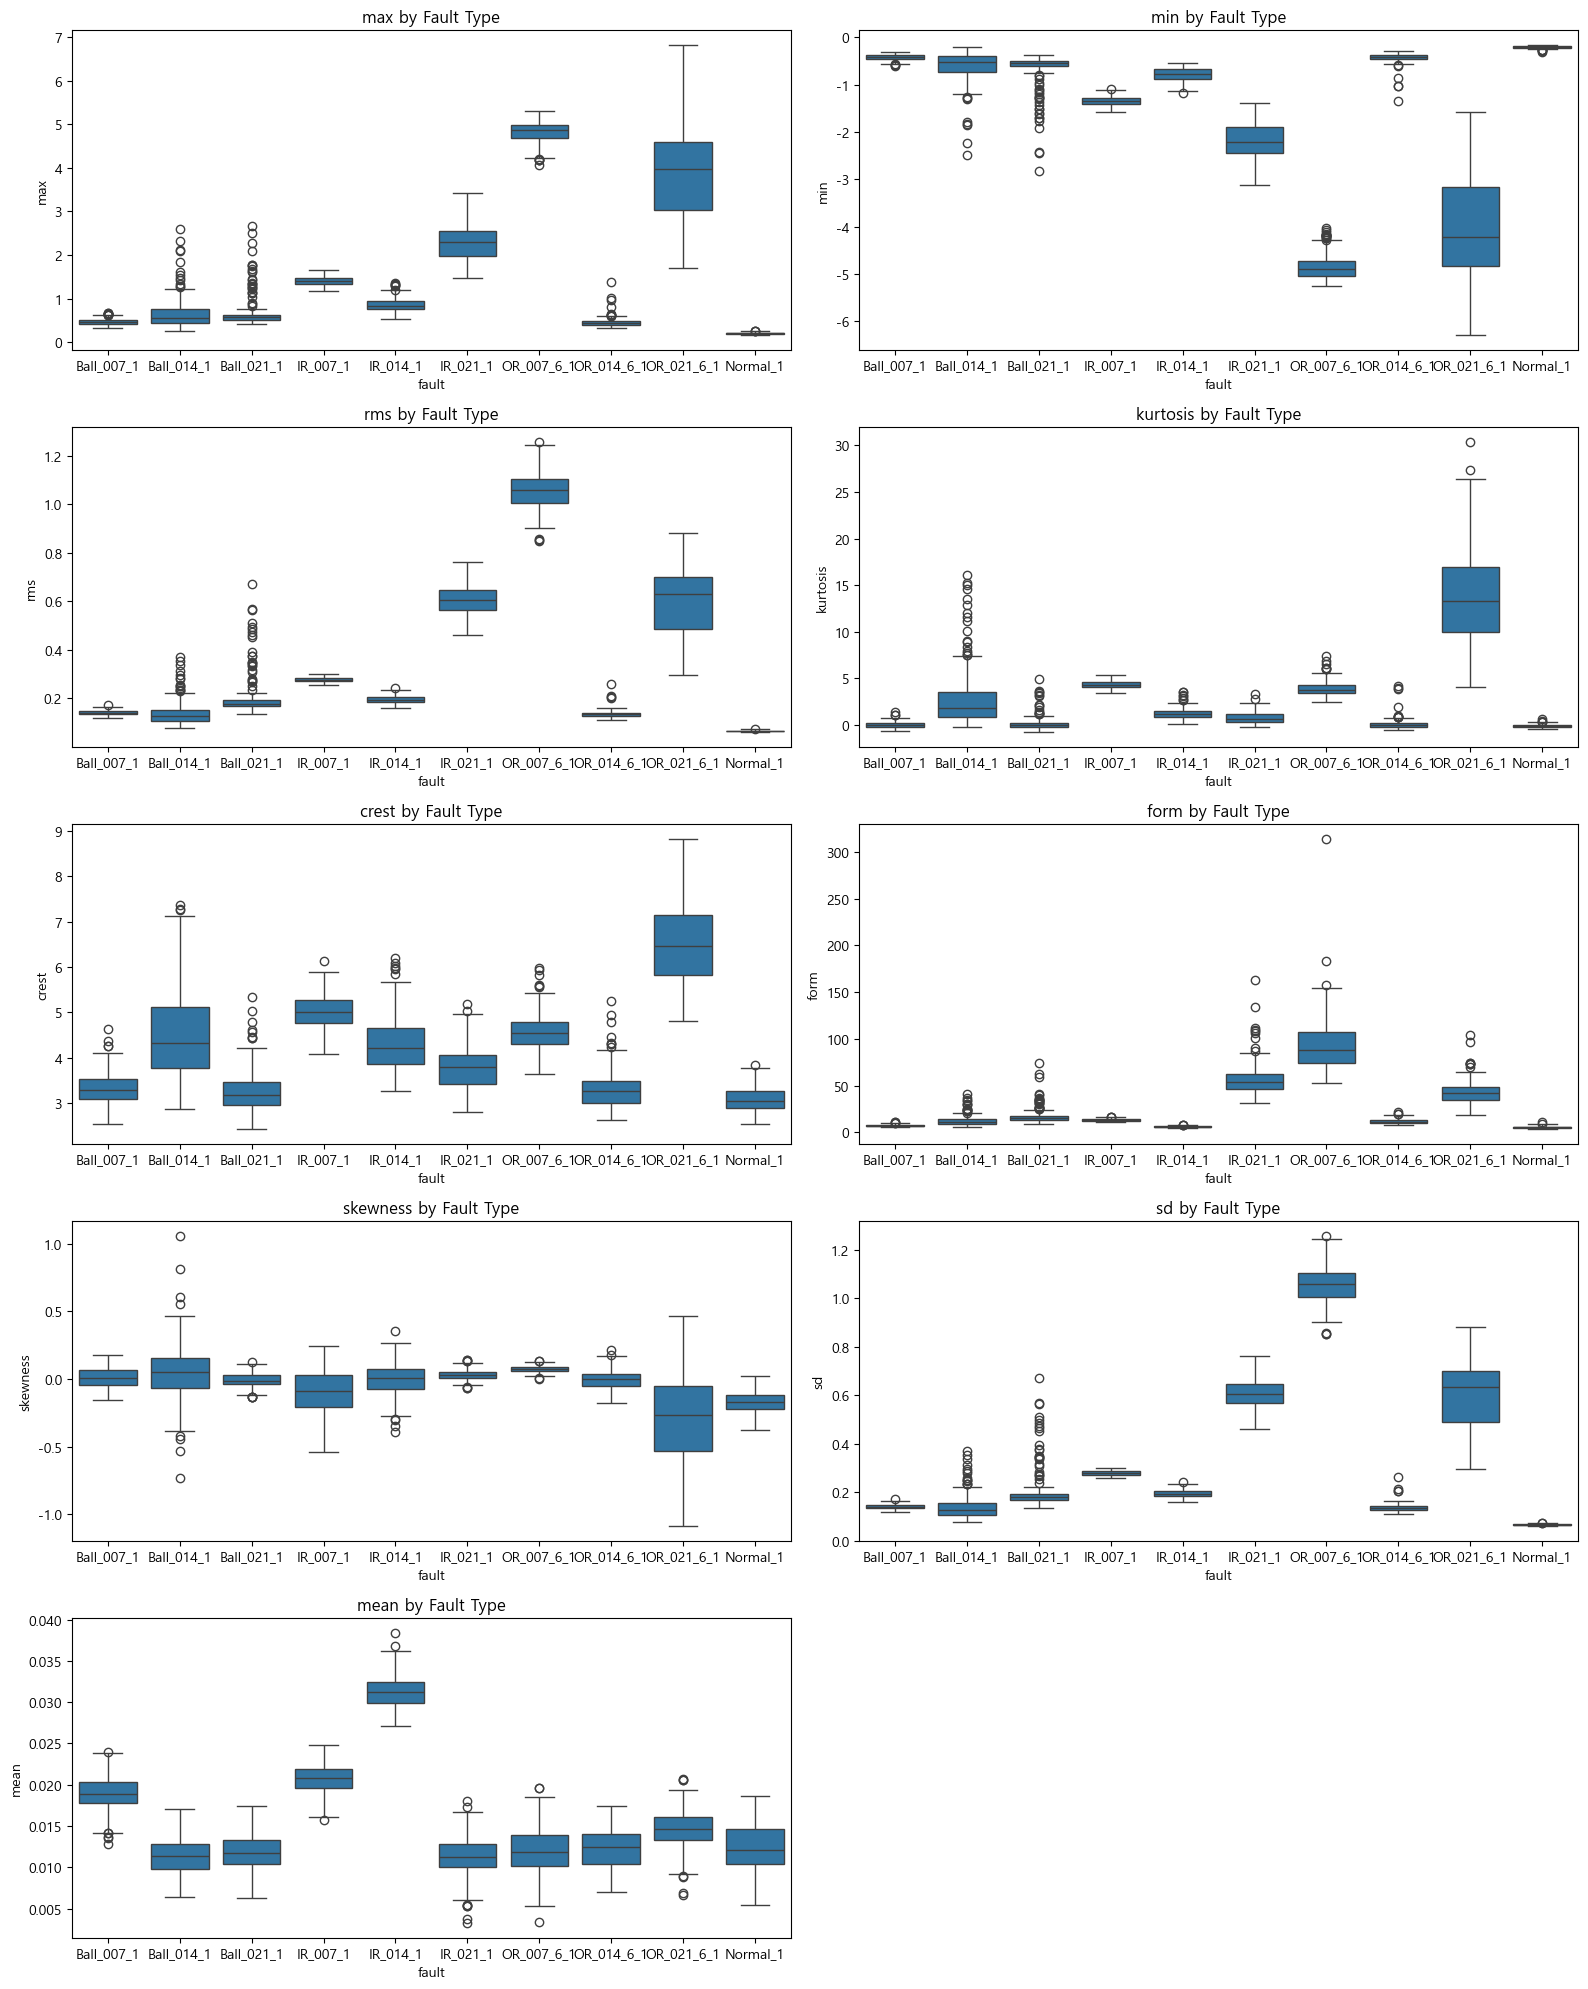

In [24]:
variables = ['max', 'min', 'rms', 'kurtosis', 'crest', 'form', 'skewness', 'sd', 'mean']  # 전체 변수 기준
plt.figure(figsize=(16, 20))
for i, var in enumerate(variables, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x='fault', y=var, data=df)
    plt.title(f'{var} by Fault Type')
plt.tight_layout()
plt.show()

In [25]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

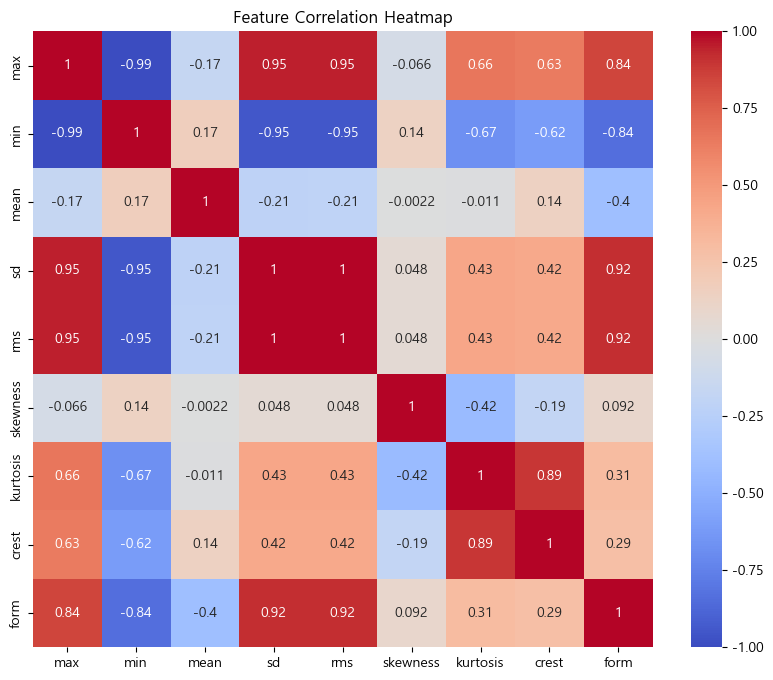

In [26]:
# 변수 간 상관관계 확인
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 수치형 변수만 추출
numerical_features = ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form']
corr_matrix = df[numerical_features].corr()

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

# rms, sd 상관관계 1, ---> 둘 중 하나 제거
# form과 sd, rms 상관관계 0.92

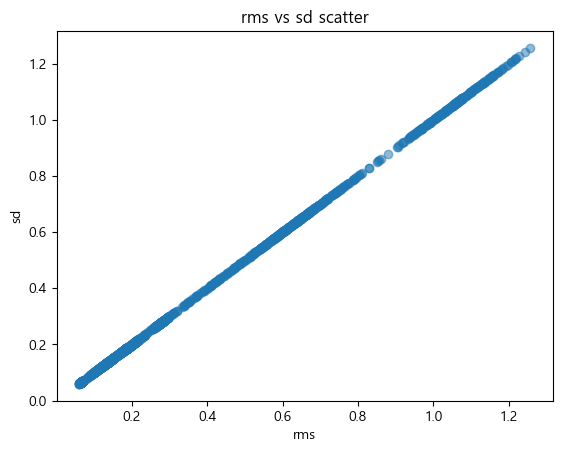

두 변수 간 평균 차이: 0.0007370256218020286
최대 차이: 0.003592537983697991


In [27]:
# 중복 변수 제거 
import matplotlib.pyplot as plt

# 1) rms vs sd 산점도
plt.scatter(df['rms'], df['sd'], alpha=0.5)
plt.xlabel('rms')
plt.ylabel('sd')
plt.title('rms vs sd scatter')
plt.show()

# 2) 차이값 분석
diff = (df['rms'] - df['sd']).abs()
print("두 변수 간 평균 차이:", diff.mean())
print("최대 차이:", diff.max())

# rms와 sd는 수치적으로 중복-> sd 제거

In [39]:
df = df.drop(columns=['sd'])  # 또는 'rms'를 drop


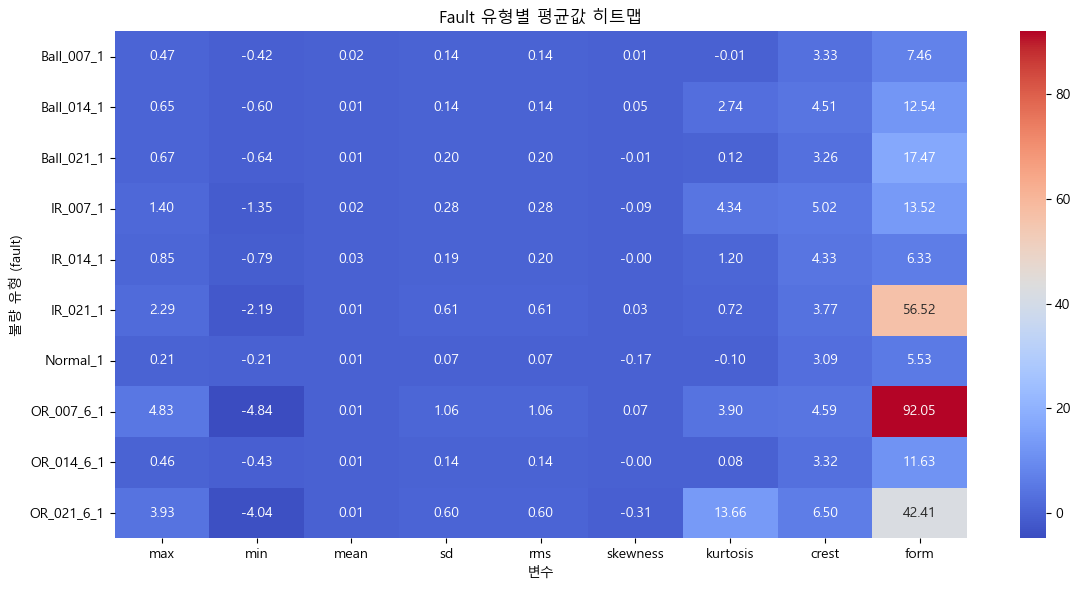

In [ ]:

# fault 변수 기준으로 그룹 평균 구하기 (수치형만 선택)
grouped_means = df.groupby('fault').mean(numeric_only=True)

# 히트맵 그리기
plt.figure(figsize=(12, 6))
sns.heatmap(grouped_means, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Fault 유형별 평균값 히트맵")
plt.xlabel("변수")
plt.ylabel("불량 유형 (fault)")
plt.tight_layout()
plt.show()

# 주요변수: form, kurtosis, crest
# mean은 모든 유형에서 거의 동일--> 제거

In [40]:
df = df.drop(columns=['mean'])  # mean제거


## 변수 제거 후 모델 

In [ ]:
# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 모델 정의
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(random_state=42)
}

# 모델 학습 및 평가
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n Model: {name}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("Macro F1 Score:", round(f1_score(y_test, y_pred, average='macro'), 4))


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:26:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)


 Model: XGBoost
              precision    recall  f1-score   support

  Ball_007_1       0.97      0.85      0.91        46
  Ball_014_1       0.98      0.89      0.93        46
  Ball_021_1       0.84      0.80      0.82        46
    IR_007_1       1.00      1.00      1.00        46
    IR_014_1       1.00      1.00      1.00        46
    IR_021_1       0.94      1.00      0.97        46
    Normal_1       1.00      1.00      1.00        46
  OR_007_6_1       1.00      1.00      1.00        46
  OR_014_6_1       0.76      0.89      0.82        46
  OR_021_6_1       0.98      1.00      0.99        46

    accuracy                           0.94       460
   macro avg       0.95      0.94      0.94       460
weighted avg       0.95      0.94      0.94       460

Macro F1 Score: 0.9439


RandomForestClassifier(random_state=42)


 Model: RandomForest
              precision    recall  f1-score   support

  Ball_007_1       0.98      0.87      0.92        46
  Ball_014_1       0.95      0.89      0.92        46
  Ball_021_1       0.88      0.80      0.84        46
    IR_007_1       1.00      1.00      1.00        46
    IR_014_1       1.00      1.00      1.00        46
    IR_021_1       0.94      1.00      0.97        46
    Normal_1       1.00      1.00      1.00        46
  OR_007_6_1       0.98      1.00      0.99        46
  OR_014_6_1       0.76      0.89      0.82        46
  OR_021_6_1       0.98      0.98      0.98        46

    accuracy                           0.94       460
   macro avg       0.95      0.94      0.94       460
weighted avg       0.95      0.94      0.94       460

Macro F1 Score: 0.9438
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295


...

c:\AIDC\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)


 Model: LogisticRegression
              precision    recall  f1-score   support

  Ball_007_1       0.78      0.85      0.81        46
  Ball_014_1       1.00      0.78      0.88        46
  Ball_021_1       0.77      0.72      0.74        46
    IR_007_1       0.98      1.00      0.99        46
    IR_014_1       0.96      0.98      0.97        46
    IR_021_1       0.94      1.00      0.97        46
    Normal_1       1.00      0.96      0.98        46
  OR_007_6_1       0.98      1.00      0.99        46
  OR_014_6_1       0.62      0.70      0.65        46
  OR_021_6_1       0.98      0.96      0.97        46

    accuracy                           0.89       460
   macro avg       0.90      0.89      0.89       460
weighted avg       0.90      0.89      0.89       460

Macro F1 Score: 0.8945


SVC(random_state=42)


 Model: SVM
              precision    recall  f1-score   support

  Ball_007_1       0.55      0.87      0.67        46
  Ball_014_1       1.00      0.04      0.08        46
  Ball_021_1       0.64      0.61      0.62        46
    IR_007_1       0.73      1.00      0.84        46
    IR_014_1       0.97      0.85      0.91        46
    IR_021_1       0.89      0.91      0.90        46
    Normal_1       0.85      0.85      0.85        46
  OR_007_6_1       0.88      1.00      0.94        46
  OR_014_6_1       0.45      0.48      0.46        46
  OR_021_6_1       0.95      0.91      0.93        46

    accuracy                           0.75       460
   macro avg       0.79      0.75      0.72       460
weighted avg       0.79      0.75      0.72       460

Macro F1 Score: 0.7215


In [43]:
df.head()

,max,min,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


In [17]:
# 3배 증강 + GridSearchCV
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

df = pd.read_csv("bearingdata.csv")

#  전처리: 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])
X = df.drop(columns=['fault'])
y = df['fault']

#  간단한 증강 함수: 각 샘플에 약간의 노이즈 추가
def augment_data(X, y, factor=3, noise_std=0.01):
    X_aug = []
    y_aug = []
    for i in range(factor - 1):  # 원본 포함해서 총 factor 배가 되게
        X_noise = X + np.random.normal(0, noise_std, X.shape)
        X_aug.append(X_noise)
        y_aug.append(y)
    X_all = np.vstack([X] + X_aug)
    y_all = np.hstack([y] + y_aug)
    return X_all, y_all

#  증강 수행
X_aug, y_aug = augment_data(X.values, y.values, factor=3)

#  학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42)

#  GridSearchCV용 파라미터 설정
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

#  모델 정의 및 그리드 탐색
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='f1_macro', cv=3, n_jobs=-1, verbose=2)

grid.fit(X_train, y_train)

# 최적 모델로 테스트셋 평가
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n Best Parameters:", grid.best_params_)
print(" Best CV Macro F1:", round(grid.best_score_, 4))
print("\n Test Set Evaluation:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(" Test Macro F1 Score:", round(f1_score(y_test, y_pred, average='macro'), 4))


Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:12:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}
 Best CV Macro F1: 0.9754

 Test Set Evaluation:
              precision    recall  f1-score   support

  Ball_007_1       0.98      0.93      0.96       138
  Ball_014_1       0.97      0.99      0.98       138
  Ball_021_1       0.99      0.97      0.98       138
    IR_007_1       1.00      1.00      1.00       138
    IR_014_1       1.00      1.00      1.00       138
    IR_021_1       0.99      1.00      1.00       138
    Normal_1       1.00      0.99      0.99       138
  OR_007_6_1       1.00      1.00      1.00       138
  OR_014_6_1       0.94      0.98      0.96       138
  OR_021_6_1       0.99      1.00      1.00       138

    accuracy                           0.99      1380
   macro avg       0.99      0.99      0.99      1380
weighted avg       0.99      0.99      0.99      1380

 Test Macro F1 Score: 0.9862


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 7 artists>

Text(0.5, 1.0, 'XGBoost Feature Importance')

Text(0.5, 0, 'Importance Score')

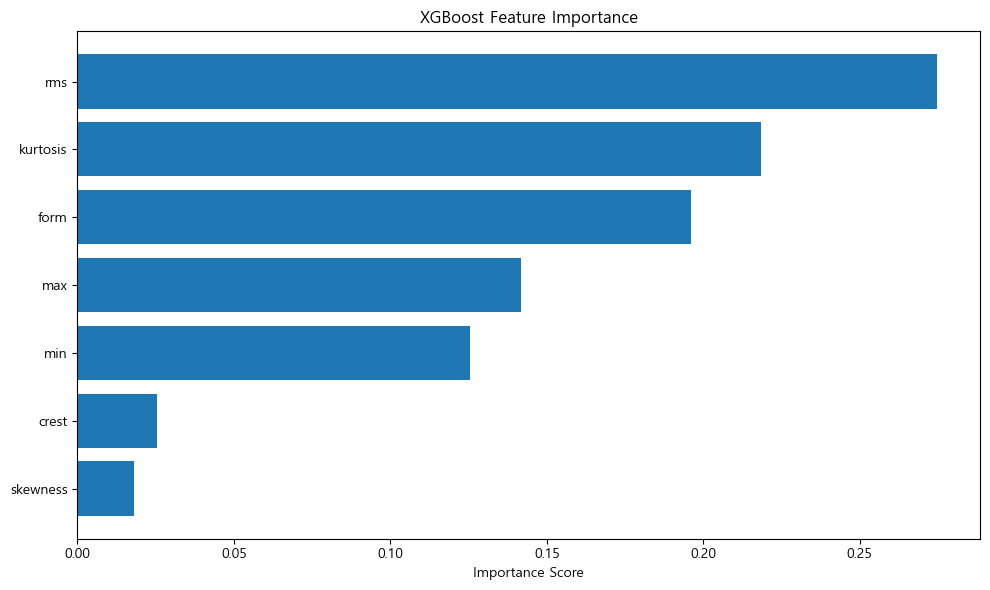

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 변수 이름 리스트
feature_names = X.columns

# 변수 중요도 추출
importances = best_model.feature_importances_

# 데이터프레임으로 정리
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values(by='importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.gca().invert_yaxis()  # 중요도 높은 게 위로
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 중요도가 가장 작은 skewness 피쳐 제거

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 전처리: 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

#  변수 제거: sd, mean, skewness
drop_cols = ['skewness']
X = df.drop(columns=['fault'] + drop_cols)
y = df['fault']

# 3. 간단한 증강 함수 (노이즈 기반)
def augment_data(X, y, factor=3, noise_std=0.01):
    X_aug = []
    y_aug = []
    for _ in range(factor - 1):
        noise = np.random.normal(0, noise_std, X.shape)
        X_noise = X + noise
        X_aug.append(X_noise)
        y_aug.append(y)
    X_all = np.vstack([X] + X_aug)
    y_all = np.hstack([y] + y_aug)
    return X_all, y_all

# 4. 증강 수행
X_aug, y_aug = augment_data(X.values, y.values, factor=3)

# 5. 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)

# 6. GridSearch 파라미터 설정
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

# 7. XGBoost 모델 + GridSearchCV
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train, y_train)

# 8. 최적 모델 평가
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n Best Parameters:", grid.best_params_)
print(" Best CV Macro F1:", round(grid.best_score_, 4))
print("\n Test Set Evaluation:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(" Test Macro F1 Score:", round(f1_score(y_test, y_pred, average='macro'), 4))



Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:49:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.3],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 300, 500]},
             scoring='f1_macro', verbose=2)


 Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
 Best CV Macro F1: 0.9761

 Test Set Evaluation:
              precision    recall  f1-score   support

  Ball_007_1       0.99      0.91      0.95       138
  Ball_014_1       0.99      1.00      1.00       138
  Ball_021_1       0.94      0.97      0.95       138
    IR_007_1       0.99      1.00      1.00       138
    IR_014_1       1.00      0.99      1.00       138
    IR_021_1       0.99      1.00      1.00       138
    Normal_1       1.00      1.00      1.00       138
  OR_007_6_1       1.00      1.00      1.00       138
  OR_014_6_1       0.91      0.94      0.93       138
  OR_021_6_1       1.00      1.00      1.00       138

    accuracy                           0.98      1380
   macro avg       0.98      0.98      0.98      1380
weighted avg       0.98      0.98      0.98      1380

 Test Macro F1 Score: 0.9812


In [ ]:
# skewness 변수 제거 후 3배 증강, GridSearch 적용
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 전처리: 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

# 변수 제거: sd, mean, skewness
drop_cols = ['sd', 'mean', 'skewness']
X = df.drop(columns=['fault'] + drop_cols)
y = df['fault']

# 3. 간단한 증강 함수 (노이즈 기반)
def augment_data(X, y, factor=3, noise_std=0.01):
    X_aug = []
    y_aug = []
    for _ in range(factor - 1):
        noise = np.random.normal(0, noise_std, X.shape)
        X_noise = X + noise
        X_aug.append(X_noise)
        y_aug.append(y)
    X_all = np.vstack([X] + X_aug)
    y_all = np.hstack([y] + y_aug)
    return X_all, y_all

# 4. 증강 수행
X_aug, y_aug = augment_data(X.values, y.values, factor=3)

# 5. 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)

# 6. GridSearch 파라미터 설정
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

# 7. XGBoost 모델 + GridSearchCV
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train, y_train)

# 8. 최적 모델 평가
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n Best Parameters:", grid.best_params_)
print(" Best CV Macro F1:", round(grid.best_score_, 4))
print("\n Test Set Evaluation:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(" Test Macro F1 Score:", round(f1_score(y_test, y_pred, average='macro'), 4))

Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [14:05:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.3],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 300, 500]},
             scoring='f1_macro', verbose=2)


 Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
 Best CV Macro F1: 0.9799

 Test Set Evaluation:
              precision    recall  f1-score   support

  Ball_007_1       0.96      0.98      0.97       138
  Ball_014_1       1.00      1.00      1.00       138
  Ball_021_1       0.96      0.96      0.96       138
    IR_007_1       1.00      1.00      1.00       138
    IR_014_1       1.00      0.99      1.00       138
    IR_021_1       0.99      1.00      1.00       138
    Normal_1       1.00      1.00      1.00       138
  OR_007_6_1       1.00      1.00      1.00       138
  OR_014_6_1       0.96      0.95      0.95       138
  OR_021_6_1       1.00      1.00      1.00       138

    accuracy                           0.99      1380
   macro avg       0.99      0.99      0.99      1380
weighted avg       0.99      0.99      0.99      1380

 Test Macro F1 Score: 0.9877


<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 59.7222222222222, 'Predicted')

Text(96.72222222222221, 0.5, 'True')

Text(0.5, 1.0, 'Confusion Matrix (10-Class Fault Prediction)')

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0.5, 0, 'Ball_007_1'),
  Text(1.5, 0, 'Ball_014_1'),
  Text(2.5, 0, 'Ball_021_1'),
  Text(3.5, 0, 'IR_007_1'),
  Text(4.5, 0, 'IR_014_1'),
  Text(5.5, 0, 'IR_021_1'),
  Text(6.5, 0, 'Normal_1'),
  Text(7.5, 0, 'OR_007_6_1'),
  Text(8.5, 0, 'OR_014_6_1'),
  Text(9.5, 0, 'OR_021_6_1')])

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, 'Ball_007_1'),
  Text(0, 1.5, 'Ball_014_1'),
  Text(0, 2.5, 'Ball_021_1'),
  Text(0, 3.5, 'IR_007_1'),
  Text(0, 4.5, 'IR_014_1'),
  Text(0, 5.5, 'IR_021_1'),
  Text(0, 6.5, 'Normal_1'),
  Text(0, 7.5, 'OR_007_6_1'),
  Text(0, 8.5, 'OR_014_6_1'),
  Text(0, 9.5, 'OR_021_6_1')])

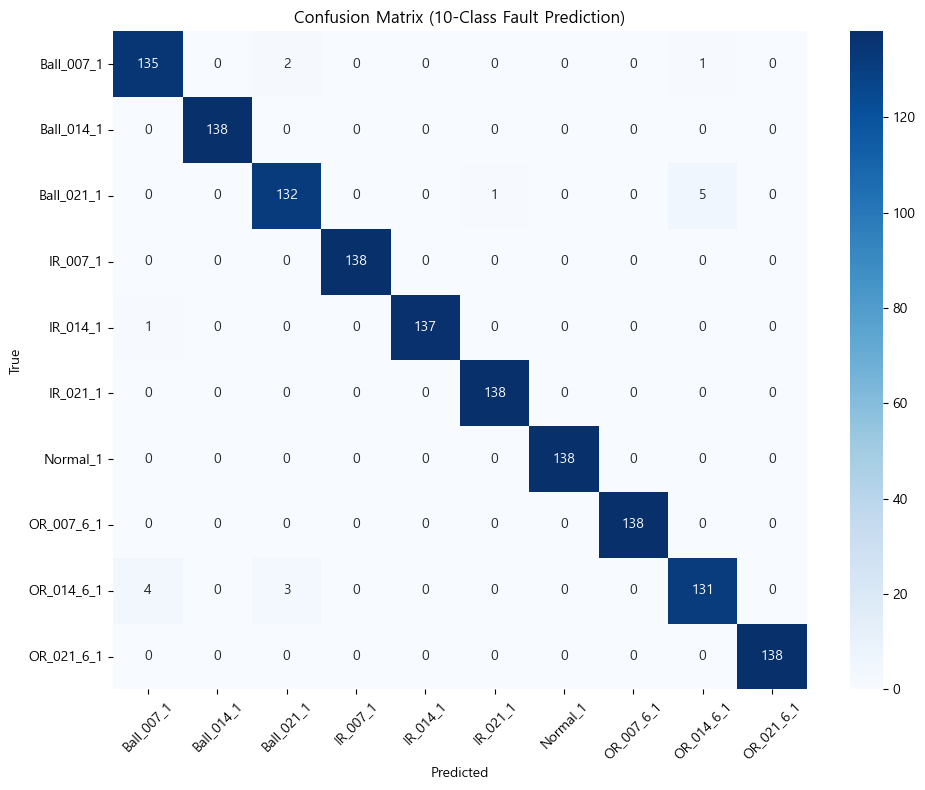

In [ ]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 9. Confusion Matrix 출력
cm = confusion_matrix(y_test, y_pred)
labels = le.classes_  # 원래 fault 라벨 순서 복원

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (10-Class Fault Prediction)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# 모델은 대부분의 fault class를 안정적으로 예측했으며, 특히 IR_021_1과 Normal_1의 경우 100% 정확도 달성
# 다만, Ball_021_1과 OR_014_6_1 간의 혼동이 일부 발생

In [49]:
import joblib

# 최종 모델 저장 (튜닝된 XGBoost 모델)
joblib.dump(best_model, 'xgb_model.pkl')

# (선택) 라벨 인코더도 함께 저장
joblib.dump(le, 'label_encoder.pkl')

['xgb_model.pkl']

['label_encoder.pkl']

In [ ]:
import numpy as np
import pandas as pd

# 예시: 기존 df의 수치형 컬럼에 가우시안 노이즈 추가
df_aug = df.copy()
cols_to_augment = ['max', 'min', 'rms', 'kurtosis', 'form', 'crest']  # 너의 통계 컬럼들

# 각 컬럼에 노이즈 추가 (mean=0, std=각 컬럼의 std * 0.05)
for col in cols_to_augment:
    noise = np.random.normal(loc=0, scale=df[col].std() * 0.05, size=len(df))
    df_aug[col] += noise

# 기존 데이터와 합치기
df_combined = pd.concat([df, df_aug], ignore_index=True)


## 최종 모델

- sd, mean, skewness 변수 제거 후, fault 컬럼을 LabelEncoder로 정수 형태로 변환
- Gaussian 노이즈를 추가해 원본 데이터를 기준으로 3배 증강 수행
- 전체 데이터를 증강 후 train_test_split으로 훈련/테스트 분리
- XGBoostClassifier에 대해 GridSearchCV를 적용해 f1_macro 기준으로 최적 파라미터 탐색 및 학습
- 최종 모델 성능은 테스트셋에서 macro F1 score 및 confusion matrix로 평가


In [19]:
# 가우시안 방식 노이즈 추가 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib 

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

drop_cols = ['sd', 'mean', 'skewness']
X = df.drop(columns=['fault'] + drop_cols)
y = df['fault']

# 3. 노이즈 기반 증강 함수
def augment_data(X, y, factor=3, noise_std=0.01):
    X_aug, y_aug = [X], [y]
    for _ in range(factor - 1):
        noise = np.random.normal(0, noise_std, X.shape)
        X_aug.append(X + noise)
        y_aug.append(y)
    return np.vstack(X_aug), np.hstack(y_aug)

# 4. 증강 실행
X_aug, y_aug = augment_data(X.values, y.values, factor=3, noise_std=0.015)

# 5. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)

# 6. GridSearchCV 세팅
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train, y_train)

# 7. 결과 출력
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(" Best Parameters:", grid.best_params_)
print("\ Best CV Macro F1:", round(grid.best_score_, 4))
print("\n Test Evaluation Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Test Macro F1 Score:", round(f1_score(y_test, y_pred, average='macro'), 4))

# 8. 모델 및 인코더 저장
joblib.dump(best_model, "fianl_xgb_model.pkl")
joblib.dump({'model': best_model, 'encoder': le}, "final_xgb_encoder.pkl")

Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [13:26:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Best Parameters: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500}
\ Best CV Macro F1: 0.9756

 Test Evaluation Report:
              precision    recall  f1-score   support

  Ball_007_1       0.96      0.96      0.96       138
  Ball_014_1       0.99      0.98      0.98       138
  Ball_021_1       0.94      0.96      0.95       138
    IR_007_1       1.00      1.00      1.00       138
    IR_014_1       1.00      1.00      1.00       138
    IR_021_1       0.99      1.00      0.99       138
    Normal_1       0.99      1.00      1.00       138
  OR_007_6_1       1.00      1.00      1.00       138
  OR_014_6_1       0.95      0.92      0.93       138
  OR_021_6_1       1.00      0.99      1.00       138

    accuracy                           0.98      1380
   macro avg       0.98      0.98      0.98      1380
weighted avg       0.98      0.98      0.98      1380

Test Macro F1 Score: 0.9818


['final_xgb_encoder.pkl']

In [ ]:
# 모델 불러오기
model = joblib.load("best_xgb_model.pkl")
y_pred = model.predict(X_test)

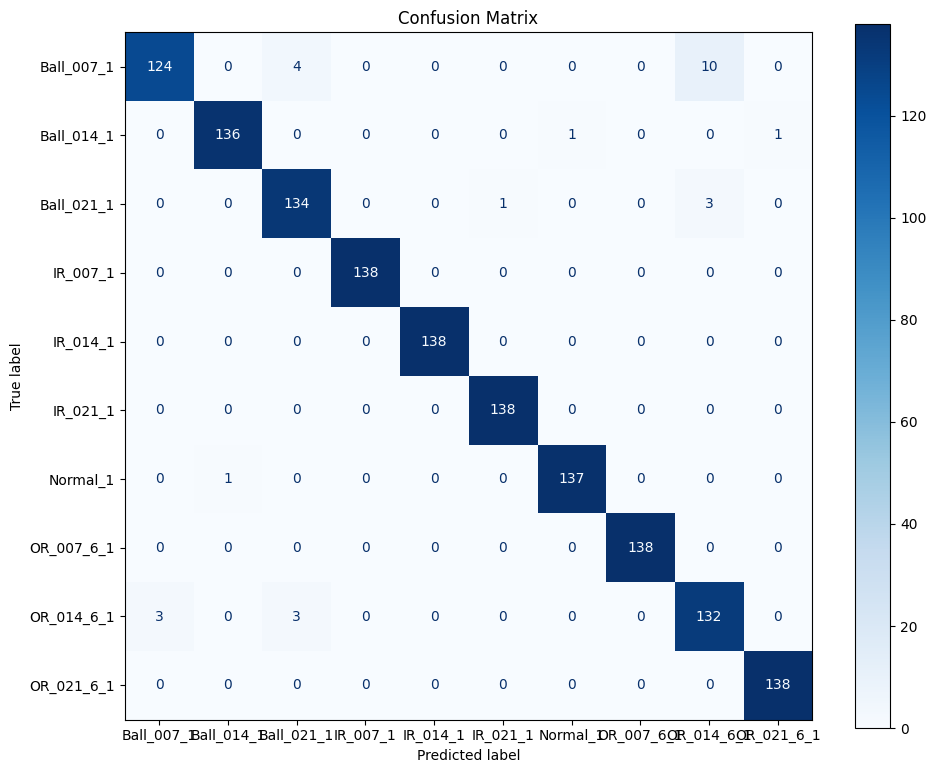

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 클래스 이름 (라벨 인코더에서 가져온 클래스 순서)
class_names = le.classes_

# 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [1]:
# SNR 기반 1.5배 증강
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib
from sklearn.utils import resample

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

drop_cols = ['sd', 'mean', 'skewness']
X = df.drop(columns=['fault'] + drop_cols)
y = df['fault']

# 3. SNR 기반 증강 함수 (1.5배, 즉 0.5배만큼 증강)
def augment_data_snr(X, y, factor=1.5, snr_db=20):
    if factor <= 1.0:
        return X, y  # 증강 없음

    n_aug = int((factor - 1.0) * len(X))
    X_sample, y_sample = resample(X, y, n_samples=n_aug, random_state=42)

    X_aug = []
    for x in X_sample:
        signal_power = np.mean(x**2)
        snr_linear = 10 ** (snr_db / 10)
        noise_power = signal_power / snr_linear
        noise = np.random.normal(0, np.sqrt(noise_power), size=x.shape)
        X_aug.append(x + noise)

    X_combined = np.vstack([X, np.array(X_aug)])
    y_combined = np.hstack([y, y_sample])
    return X_combined, y_combined

# 4. 증강 실행 (1.5배, SNR=20dB)
X_aug, y_aug = augment_data_snr(X.values, y.values, factor=1.5, snr_db=20)

# 5. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, stratify=y_aug, random_state=42
)

# 6. GridSearchCV 세팅
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train, y_train)

# 7. 결과 출력
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(" Best Parameters:", grid.best_params_)
print("\ Best CV Macro F1:", round(grid.best_score_, 4))
print("\n Test Evaluation Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Test Macro F1 Score:", round(f1_score(y_test, y_pred, average='macro'), 4))

# 8. 모델 및 인코더 저장
joblib.dump(best_model, "final_xgb_model_snr.pkl")
joblib.dump({'model': best_model, 'encoder': le}, "final_xgb_encoder_snr.pkl")


Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [09:55:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Best Parameters: {'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
\ Best CV Macro F1: 0.8808

 Test Evaluation Report:
              precision    recall  f1-score   support

  Ball_007_1       0.80      0.76      0.78        70
  Ball_014_1       0.82      0.82      0.82        66
  Ball_021_1       0.81      0.82      0.82        68
    IR_007_1       0.97      0.97      0.97        70
    IR_014_1       0.94      0.93      0.93        69
    IR_021_1       0.93      0.91      0.92        70
    Normal_1       0.89      0.97      0.93        69
  OR_007_6_1       0.93      0.93      0.93        67
  OR_014_6_1       0.74      0.72      0.73        71
  OR_021_6_1       0.94      0.96      0.95        70

    accuracy                           0.88       690
   macro avg       0.88      0.88      0.88       690
weighted avg       0.88      0.88      0.88       690

Test Macro F1 Score: 0.8777


['final_xgb_encoder_snr.pkl']

In [2]:
# 1. 원본 데이터로만 test셋 구성
X_orig = X.values  # 증강 전 원본
y_orig = y.values

# 원본에서 train/test 분할 (stratify 주의)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.2, stratify=y_orig, random_state=42
)

# 2. 증강 데이터로 학습한 모델로 원본 test셋 예측
y_pred_orig_test = best_model.predict(X_test_orig)

# 3. 평가 출력
print(" 과적합 여부 확인용 (원본 테스트셋 기준)")
print(classification_report(y_test_orig, y_pred_orig_test, target_names=le.classes_))
print("Test Macro F1 on Original Data:", round(f1_score(y_test_orig, y_pred_orig_test, average='macro'), 4))


 과적합 여부 확인용 (원본 테스트셋 기준)
              precision    recall  f1-score   support

  Ball_007_1       0.95      0.87      0.91        46
  Ball_014_1       0.98      0.98      0.98        46
  Ball_021_1       1.00      0.96      0.98        46
    IR_007_1       1.00      1.00      1.00        46
    IR_014_1       0.96      1.00      0.98        46
    IR_021_1       0.98      1.00      0.99        46
    Normal_1       1.00      1.00      1.00        46
  OR_007_6_1       1.00      1.00      1.00        46
  OR_014_6_1       0.88      0.96      0.92        46
  OR_021_6_1       1.00      0.98      0.99        46

    accuracy                           0.97       460
   macro avg       0.97      0.97      0.97       460
weighted avg       0.97      0.97      0.97       460

Test Macro F1 on Original Data: 0.9739


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.utils import resample
import joblib

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

drop_cols = ['sd', 'mean', 'skewness']
X = df.drop(columns=['fault'] + drop_cols)
y = df['fault']

# 3. train/test 분할 (원본 데이터 기준)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y.values, random_state=42
)

# 4. SNR 기반 증강 함수
def augment_data_snr(X, y, factor=1.5, snr_db=20):
    if factor <= 1.0:
        return X, y

    n_aug = int((factor - 1.0) * len(X))
    X_sample, y_sample = resample(X, y, n_samples=n_aug, random_state=42)

    X_aug = []
    for x in X_sample:
        signal_power = np.mean(x**2)
        snr_linear = 10 ** (snr_db / 10)
        noise_power = signal_power / snr_linear
        noise = np.random.normal(0, np.sqrt(noise_power), size=x.shape)
        X_aug.append(x + noise)

    X_combined = np.vstack([X, np.array(X_aug)])
    y_combined = np.hstack([y, y_sample])
    return X_combined, y_combined

# 5. train 데이터만 증강
X_train_aug, y_train_aug = augment_data_snr(X_train_orig, y_train_orig, factor=1.5, snr_db=20)

# 6. 모델 학습 (GridSearch)
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_aug, y_train_aug)
best_model = grid.best_estimator_

# 7. 원본 test셋 평가
y_pred_test = best_model.predict(X_test_orig)

print(" Best Parameters:", grid.best_params_)
print(" Best CV Macro F1:", round(grid.best_score_, 4))
print("\n Evaluation on Original (Clean) Test Set:")
print(classification_report(y_test_orig, y_pred_test, target_names=le.classes_))
print(" Test Macro F1 on Original Test Set:", round(f1_score(y_test_orig, y_pred_test, average='macro'), 4))

# 8. 모델 저장
joblib.dump({'model': best_model, 'encoder': le}, "xgb_snr_checked.pkl")

Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [09:58:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
 Best CV Macro F1: 0.8169

 Evaluation on Original (Clean) Test Set:
              precision    recall  f1-score   support

  Ball_007_1       0.95      0.83      0.88        46
  Ball_014_1       0.93      0.87      0.90        46
  Ball_021_1       0.84      0.83      0.84        46
    IR_007_1       1.00      1.00      1.00        46
    IR_014_1       1.00      1.00      1.00        46
    IR_021_1       0.94      1.00      0.97        46
    Normal_1       0.98      1.00      0.99        46
  OR_007_6_1       1.00      1.00      1.00        46
  OR_014_6_1       0.77      0.87      0.82        46
  OR_021_6_1       0.98      0.98      0.98        46

    accuracy                           0.94       460
   macro avg       0.94      0.94      0.94       460
weighted avg       0.94      0.94      0.94       460

 Test Macro F1 on Original Test Set: 0.937


['xgb_snr_checked.pkl']

In [7]:
 # Gaussian Noise + 1.5x 증강 + 과적합 평가
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from lightgbm import LGBMClassifier

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

drop_cols = ['sd', 'mean', 'skewness']
X = df.drop(columns=['fault'] + drop_cols)
y = df['fault']

# 3. 원본에서 train/test 분할
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y.values, random_state=42
)

# 4. 가우시안 노이즈 기반 증강 함수
def augment_data_gaussian(X, y, factor=1.5, noise_std=0.015):
    if factor <= 1.0:
        return X, y
    n_aug = int((factor - 1.0) * len(X))
    X_sample, y_sample = resample(X, y, n_samples=n_aug, random_state=42)

    noise = np.random.normal(0, noise_std, X_sample.shape)
    X_aug = X_sample + noise

    X_combined = np.vstack([X, X_aug])
    y_combined = np.hstack([y, y_sample])
    return X_combined, y_combined

# 5. train 데이터만 증강
X_train_aug, y_train_aug = augment_data_gaussian(X_train_orig, y_train_orig, factor=1.5, noise_std=0.015)

# 6. GridSearchCV로 LightGBM 학습
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'num_leaves': [15, 31, 63]
}

lgbm = LGBMClassifier(class_weight='balanced', random_state=42)
grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_aug, y_train_aug)
best_model = grid.best_estimator_

# 7. 원본 test셋에서 최종 평가 (과적합 여부 확인)
y_pred = best_model.predict(X_test_orig)

print("Best Parameters (Gaussian):", grid.best_params_)
print("Best CV Macro F1 (Gaussian):", round(grid.best_score_, 4))
print("\n Evaluation on Original Test Set (Gaussian):")
print(classification_report(y_test_orig, y_pred, target_names=le.classes_))
print("Test Macro F1 on Original Test Set:", round(f1_score(y_test_orig, y_pred, average='macro'), 4))


Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 2760, number of used features: 6
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

GridSearchCV(cv=3,
             estimator=LGBMClassifier(class_weight='balanced', random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 300, 500],
                         'num_leaves': [15, 31, 63]},
             scoring='f1_macro', verbose=2)

Best Parameters (Gaussian): {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'num_leaves': 63}
Best CV Macro F1 (Gaussian): 0.9601

 Evaluation on Original Test Set (Gaussian):
              precision    recall  f1-score   support

  Ball_007_1       0.93      0.80      0.86        46
  Ball_014_1       0.95      0.91      0.93        46
  Ball_021_1       0.88      0.80      0.84        46
    IR_007_1       1.00      1.00      1.00        46
    IR_014_1       0.98      0.98      0.98        46
    IR_021_1       0.94      1.00      0.97        46
    Normal_1       1.00      1.00      1.00        46
  OR_007_6_1       1.00      1.00      1.00        46
  OR_014_6_1       0.76      0.89      0.82        46
  OR_021_6_1       0.98      1.00      0.99        46

    accuracy                           0.94       460
   macro avg       0.94      0.94      0.94       460
weighted avg       0.94      0.94      0.94       460

Test Macro F1 on Original Test Set: 0.9391


c:\AIDC\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib  

joblib.dump({'model': best_model, 'encoder': le}, "lightgbm_gaussian_aug15.pkl")


['lightgbm_gaussian_aug15.pkl']

In [9]:
# XGBoost + Gaussian Noise 증강 (1.5배) + 과적합 평가
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier
import joblib

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

drop_cols = ['sd', 'mean', 'skewness']
X = df.drop(columns=['fault'] + drop_cols)
y = df['fault']

# 3. 원본에서 train/test 분할
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y.values, random_state=42
)

# 4. 가우시안 노이즈 기반 증강 함수
def augment_data_gaussian(X, y, factor=1.5, noise_std=0.015):
    if factor <= 1.0:
        return X, y
    n_aug = int((factor - 1.0) * len(X))
    X_sample, y_sample = resample(X, y, n_samples=n_aug, random_state=42)
    noise = np.random.normal(0, noise_std, X_sample.shape)
    X_aug = X_sample + noise
    X_combined = np.vstack([X, X_aug])
    y_combined = np.hstack([y, y_sample])
    return X_combined, y_combined

# 5. train 데이터만 증강
X_train_aug, y_train_aug = augment_data_gaussian(X_train_orig, y_train_orig, factor=1.5, noise_std=0.015)

# 6. GridSearchCV로 XGBoost 학습
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_aug, y_train_aug)
best_model = grid.best_estimator_

# 7. 원본 test셋에서 최종 평가
y_pred = best_model.predict(X_test_orig)

print("Best Parameters (XGBoost):", grid.best_params_)
print("Best CV Macro F1 (XGBoost):", round(grid.best_score_, 4))
print("\n Evaluation on Original Test Set (XGBoost):")
print(classification_report(y_test_orig, y_pred, target_names=le.classes_))
print(" Test Macro F1 on Original Test Set:", round(f1_score(y_test_orig, y_pred, average='macro'), 4))

# 8. 모델 및 인코더 저장
joblib.dump({'model': best_model, 'encoder': le}, "xgboost_gaussian_aug15.pkl")

Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [10:31:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.3],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 300, 500]},
             scoring='f1_macro', verbose=2)

Best Parameters (XGBoost): {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
Best CV Macro F1 (XGBoost): 0.962

 Evaluation on Original Test Set (XGBoost):
              precision    recall  f1-score   support

  Ball_007_1       0.95      0.80      0.87        46
  Ball_014_1       0.95      0.85      0.90        46
  Ball_021_1       0.79      0.83      0.81        46
    IR_007_1       1.00      1.00      1.00        46
    IR_014_1       0.98      1.00      0.99        46
    IR_021_1       0.94      1.00      0.97        46
    Normal_1       1.00      1.00      1.00        46
  OR_007_6_1       1.00      1.00      1.00        46
  OR_014_6_1       0.77      0.87      0.82        46
  OR_021_6_1       0.98      0.98      0.98        46

    accuracy                           0.93       460
   macro avg       0.94      0.93      0.93       460
weighted avg       0.94      0.93      0.93       460

 Test Macro F1 on Original Test Set: 0.9328


['xgboost_gaussian_aug15.pkl']

In [5]:
# 출력 생략 없이 모두 보이게 설정
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [10]:
# XGBoost + Gaussian Noise 증강 (1.5배) + 단순화된 결함 라벨(4종)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier
import joblib

# 1. 데이터 불러오기
df = pd.read_csv("bearingdata.csv")

# 2. 결함 그룹 단순화 함수 (Ball / IR / OR / Normal)
def simplify_fault(label):
    if 'Ball' in label:
        return 'Ball'
    elif 'IR' in label:
        return 'IR'
    elif 'OR' in label:
        return 'OR'
    else:
        return 'Normal'

df['fault_simple'] = df['fault'].apply(simplify_fault)

# 3. 라벨 인코딩 + 불필요 변수 제거
le = LabelEncoder()
df['fault_simple_enc'] = le.fit_transform(df['fault_simple'])

drop_cols = ['fault', 'fault_simple', 'sd', 'mean', 'skewness']
X = df.drop(columns=drop_cols)
y = df['fault_simple_enc']

# 4. train/test 분할
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y.values, random_state=42
)

# 5. 가우시안 노이즈 기반 증강 함수
def augment_data_gaussian(X, y, factor=1.5, noise_std=0.015):
    if factor <= 1.0:
        return X, y
    n_aug = int((factor - 1.0) * len(X))
    X_sample, y_sample = resample(X, y, n_samples=n_aug, random_state=42)
    noise = np.random.normal(0, noise_std, X_sample.shape)
    X_aug = X_sample + noise
    X_combined = np.vstack([X, X_aug])
    y_combined = np.hstack([y, y_sample])
    return X_combined, y_combined

# 6. 증강 적용
X_train_aug, y_train_aug = augment_data_gaussian(X_train_orig, y_train_orig, factor=1.5, noise_std=0.015)

# 7. XGBoost 학습 + GridSearch
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_aug, y_train_aug)
best_model = grid.best_estimator_

# 8. 원본 test셋에서 평가
y_pred = best_model.predict(X_test_orig)

print(" Best Parameters:", grid.best_params_)
print(" Best CV Macro F1:", round(grid.best_score_, 4))
print("\n Evaluation on Test Set:")
print(classification_report(y_test_orig, y_pred, target_names=le.classes_))
print("Test Macro F1:", round(f1_score(y_test_orig, y_pred, average='macro'), 4))

# 9. 모델 및 인코더 저장
joblib.dump({'model': best_model, 'encoder': le}, "xgboost_4class_gaussian_aug15.pkl")


Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [11:46:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.3],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 300, 500]},
             scoring='f1_macro', verbose=2)

 Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
 Best CV Macro F1: 0.953

 Evaluation on Test Set:
              precision    recall  f1-score   support

        Ball       1.00      1.00      1.00       138
          IR       1.00      1.00      1.00       138
      Normal       1.00      1.00      1.00        46
          OR       1.00      1.00      1.00       138

    accuracy                           1.00       460
   macro avg       1.00      1.00      1.00       460
weighted avg       1.00      1.00      1.00       460

Test Macro F1: 1.0


['xgboost_4class_gaussian_aug15.pkl']